In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from model_helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history, create_loss_csv, lstm_attention, bi_lstm_attention

2024-12-09 03:33:13.833200: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
df = pd.read_csv("./model_generated_data/Station3_linear_model_precipitation_chance_hourly.csv", index_col=0, parse_dates=True)
original_df = pd.read_csv("../datasets/Simulate_Cleaned_Merged/Station3_simulated_cleaned_merged_data.csv", index_col=0, parse_dates=True)
df = pd.concat([df, original_df], axis = 1)
pd.set_option('display.max_columns', None)

# # Display the head of the dataframe
# print(df.head()) 
# df.head()
#joined_df = pd.concat([df, original_df.set_axis(df.index)], axis=1)
#joined_df.head()
len(df)
print(df.head())
#len(df)
# original_df.head()

                     Wx  Wy  Day sin  Day cos  Year sin  Year cos  \
2015-01-01 00:00:00 NaN NaN      NaN      NaN       NaN       NaN   
2015-01-01 01:00:00 NaN NaN      NaN      NaN       NaN       NaN   
2015-01-01 02:00:00 NaN NaN      NaN      NaN       NaN       NaN   
2015-01-01 03:00:00 NaN NaN      NaN      NaN       NaN       NaN   
2015-01-01 04:00:00 NaN NaN      NaN      NaN       NaN       NaN   

                     Sum_Rain_1h  Sum_Rain_3h  Sum_Rain_6h  Sum_Rain_12h  \
2015-01-01 00:00:00          NaN          NaN          NaN           NaN   
2015-01-01 01:00:00          NaN          NaN          NaN           NaN   
2015-01-01 02:00:00          NaN          NaN          NaN           NaN   
2015-01-01 03:00:00          NaN          NaN          NaN           NaN   
2015-01-01 04:00:00          NaN          NaN          NaN           NaN   

                     Sum_Rain_24h  Predicted_Rain_Next_Hour_1h  \
2015-01-01 00:00:00           NaN                          NaN

In [14]:
df = df.dropna()
df.to_csv("Station3_merged_precipitation_forecasting.csv")

In [3]:
df = preprocess(df)
df = normalize(df)
df.head()

,Wx,Wy,Day sin,Day cos,Year sin,Year cos,Sum_Rain_1h,Sum_Rain_3h,Sum_Rain_6h,Sum_Rain_12h,Sum_Rain_24h,Predicted_Rain_Next_Hour_1h,Predicted_Rain_Next_Hour_3h,Predicted_Rain_Next_Hour_6h,Predicted_Rain_Next_Hour_12h,Predicted_Rain_Next_Hour_24h,Rain_Chance_Percentage_1d,Rain_Chance_Percentage_2d,Rain_Chance_Percentage_3d,Rain_Chance_Percentage_4d,Rain_Chance_Percentage_5d,Rain_Chance_Percentage_6d,Rain_Chance_Percentage_7d,Rain_Chance_Percentage,Predict_1days_Percentage,Predict_2days_Percentage,Predict_3days_Percentage,Predict_4days_Percentage,Predict_5days_Percentage,Predict_6days_Percentage,Predict_7days_Percentage,Ppt_pred_1hr,Ppt_pred_3hr,Ppt_pred_6hr,Ppt_pred_12hr,Ppt_pred_24hr,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Srad
2015-01-04 00:00:00,0.304083,0.057163,-5.999566e-13,1.414165,0.024645,1.437505,-0.088321,-0.121662,-0.15286,-0.197815,-0.197920,-0.305401,-0.305371,-0.310133,-0.326922,-0.345586,-1.260661,-1.396197,-1.050907,-2.131500,-1.843766,-0.065967,-0.050847,-0.474472,-0.532360,-0.502594,-0.457980,-0.486796,-0.479743,-0.423859,-0.464524,-0.306704,-0.308055,-0.307882,-0.326367,-0.297603,-0.088321,0.901118,1.495371,1.006331,0.998466,-1.934871,-1.829163,-1.754898,-1.801548,-0.08837,-1.675108,0.603093,-0.683653
2015-01-04 01:00:00,0.324851,0.016866,3.660254e-01,1.365978,0.025664,1.437451,-0.088321,-0.121662,-0.15286,-0.197815,-0.262557,-0.210837,-0.304327,-0.291182,-0.320151,-0.348809,0.065446,0.491015,0.469285,0.485455,0.454524,-0.065967,-0.050847,-0.474472,-0.481569,-0.474238,-0.543157,-0.504769,-0.438769,-0.531608,-0.527480,0.023652,0.051077,-0.024540,-0.030588,-0.040195,-0.088321,0.880101,1.477164,0.990544,0.998466,-2.004553,-1.887818,-1.780534,-1.795294,-0.08837,-1.787469,0.325808,-0.683619
2015-01-04 02:00:00,0.696361,-0.661030,7.071068e-01,1.224700,0.026682,1.437396,-0.088321,-0.121662,-0.15286,-0.197815,-0.262557,-0.246568,-0.299993,-0.303314,-0.285028,-0.347259,0.065446,0.491015,0.469285,0.485455,0.454524,-0.065967,-0.050847,-0.474472,-0.481148,-0.488131,-0.517242,-0.481168,-0.519903,-0.468782,-0.431400,0.394632,0.388894,0.594564,0.410406,0.403276,-0.088321,0.880101,1.477164,0.974756,0.998466,-2.066901,-1.943922,-1.807520,-1.789040,-0.08837,-1.260029,-0.217223,-0.683551
2015-01-04 03:00:00,0.766900,-0.290635,1.000000e+00,0.999959,0.027700,1.437341,-0.088321,-0.121662,-0.15286,-0.197815,-0.262557,-0.287101,-0.125136,-0.296555,-0.322396,-0.290067,0.065446,0.491015,0.469285,0.485455,0.454524,-0.065967,-0.050847,-0.474472,-0.499721,-0.488352,-0.464831,-0.427903,-0.406389,-0.528485,-0.466750,-0.021105,-0.022357,-0.070530,-0.079286,-0.024683,-0.088321,0.859084,1.458957,0.974756,0.998466,-2.098685,-1.988551,-1.835854,-1.784349,-0.08837,-1.263420,-0.028753,-0.683653
2015-01-04 04:00:00,1.114035,-0.138592,1.224745e+00,0.707070,0.028718,1.437285,-0.088321,-0.121662,-0.15286,-0.197815,-0.262557,-0.208672,-0.179149,-0.260539,-0.329145,-0.235030,0.065446,0.491015,0.469285,0.485455,0.454524,-0.065967,-0.050847,-0.474472,-0.540727,-0.445973,-0.475340,-0.539043,-0.461456,-0.451944,-0.443755,-0.313603,-0.317011,-0.293850,-0.279768,-0.309168,-0.088321,0.859084,1.440750,0.958969,0.998466,-2.121913,-2.022979,-1.864188,-1.779659,-0.08837,-1.404267,0.306227,-0.683653


In [4]:
label_features = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']
temp_features = ['T_5', 'T_10', 'T_20', 'T_50']

configurations = [
        {"features": 'SWC_5', "input_steps": 24, "output_steps": 6},
        {"features": 'SWC_5', "input_steps": 48, "output_steps": 12},
        {"features": 'SWC_5', "input_steps": 7*24, "output_steps": 24},
        {"features": 'SWC_5', "input_steps": 7*24, "output_steps": 48},
        # {"features": 'SWC_10', "input_steps": 24, "output_steps": 1},
        # {"features": 'SWC_10', "input_steps": 24, "output_steps": 6},
        # {"features": 'SWC_10', "input_steps": 48, "output_steps": 12},
        # {"features": 'SWC_10', "input_steps": 7*24, "output_steps": 24},
        # {"features": 'SWC_10', "input_steps": 7*24, "output_steps": 48},
        # {"features": 'SWC_20', "input_steps": 24, "output_steps": 1},
        # {"features": 'SWC_20', "input_steps": 24, "output_steps": 6},
        # {"features": 'SWC_20', "input_steps": 48, "output_steps": 12},
        # {"features": 'SWC_20', "input_steps": 7*24, "output_steps": 24},
        # {"features": 'SWC_20', "input_steps": 7*24, "output_steps": 48},
    ]

all_losses = {}
model_dir = './saved_models_precipitation/'

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

In [5]:
for config in configurations:
    print(f"\nEvaluating models for configuration: {config}")
    model_filename = f'{config["features"]}_{config["input_steps"]}_{config["output_steps"]}_model_results.csv'
    loss_filename = f'{config["features"]}_{config["input_steps"]}_{config["output_steps"]}_loss_history.csv'
    create_csv(model_filename)
    create_loss_csv(loss_filename)
    create_feature_csv(f'{config["features"]}_{config["input_steps"]}_{config["output_steps"]}_feature_importance_results.csv')
    CONV_WIDTH = 3
    # Define models in a dictionary
    label_width = config['output_steps']
    n = len(df)
    df_copy = df.copy()
    label = config['features']
    label_index = label_features.index(label)

    # Identify the temperature feature to keep based on the label feature
    temp_to_keep = temp_features[label_index]
    features_to_drop = [col for col in label_features if col != label]
    features_to_drop += [col for col in temp_features if col != temp_to_keep]
    # Drop the features
    df_copy = df_copy.drop(columns=features_to_drop)


    train_df = df_copy.iloc[0:int(n*0.7)]
    val_df = df_copy.iloc[int(n*0.7):int(n*0.9)]
    test_df = df_copy.iloc[int(n*0.9):]
    print(train_df.isnull().sum())
    print(val_df.isnull().sum())
    print(test_df.isnull().sum())
    num_features = df_copy.shape[1]
    models = {
            'Baseline': baseline(label_width, num_features),
            'Multi-step Linear': linear(label_width, num_features),
            'Multi-step Dense': dense(label_width, num_features),
            'CNN': cnn(label_width, num_features, CONV_WIDTH),
            'RNN': simple_rnn(label_width, num_features),
            'LSTM': lstm(label_width, num_features),
            'Autoregressive': autoregressive(label_width, num_features),
            'Bi-LSTM': bi_lstm(label_width, num_features),
            'LSTM_Attention': lstm_attention(label_width, num_features),
            'BiLSTM_Attention': bi_lstm_attention(label_width, num_features)
        }

    # make way to drop other features besides one in config
    # Train and evaluate models for the current configuration
    performance, val_performance, history_dicts = train_and_evaluate_models(3, config, models, train_df, val_df, test_df, model_dir, model_filename, loss_filename  )
    model_losses = (performance, val_performance)
    # Store the losses for this configuration
    all_losses[f"{config['features']} - {config['input_steps']} input / {config['output_steps']} output"] = model_losses
    #plot_training_history(history_dicts)
    

# Call the function to print the summaries
print_model_summaries(models, all_losses)


Evaluating models for configuration: {'features': 'SWC_5', 'input_steps': 24, 'output_steps': 6}
Wx                              0
Wy                              0
Day sin                         0
Day cos                         0
Year sin                        0
Year cos                        0
Sum_Rain_1h                     0
Sum_Rain_3h                     0
Sum_Rain_6h                     0
Sum_Rain_12h                    0
Sum_Rain_24h                    0
Predicted_Rain_Next_Hour_1h     0
Predicted_Rain_Next_Hour_3h     0
Predicted_Rain_Next_Hour_6h     0
Predicted_Rain_Next_Hour_12h    0
Predicted_Rain_Next_Hour_24h    0
Rain_Chance_Percentage_1d       0
Rain_Chance_Percentage_2d       0
Rain_Chance_Percentage_3d       0
Rain_Chance_Percentage_4d       0
Rain_Chance_Percentage_5d       0
Rain_Chance_Percentage_6d       0
Rain_Chance_Percentage_7d       0
Rain_Chance_Percentage          0
Predict_1days_Percentage        0
Predict_2days_Percentage        0
Predict_3days_Perc

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1276/1276 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0768 - mean_absolute_error: 1.1591 - mean_absolute_percentage_error: 423.7985 - mean_squared_error: 2.0768 - val_loss: 1.9803 - val_mean_absolute_error: 1.1486 - val_mean_absolute_percentage_error: 243.2592 - val_mean_squared_error: 1.9803
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2.0763 - mean_absolute_error: 1.1589 - mean_absolute_percentage_error: 424.9941 - mean_squared_error: 2.0763 - val_loss: 1.9803 - val_mean_absolute_error: 1.1486 - val_mean_absolute_percentage_error: 243.2590 - val_mean_squared_error: 1.9803
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0778 - mean_absolute_error: 1.1593 - mean_absolute_percentage_error: 427.8504 - mean_squared_error: 2.0778 - val_loss: 1.9803 - val_mean_absolute_error: 1.1486 - val_mean_absolute_percentage_error: 243.2589 - val_mean_squared_error: 1.9803
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.0781 - mean_absolute_error: 1.1592 

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1275/1275 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0215 - mean_absolute_error: 1.1432 - mean_absolute_percentage_error: 399.6889 - mean_squared_error: 2.0215 - val_loss: 1.9670 - val_mean_absolute_error: 1.1434 - val_mean_absolute_percentage_error: 283.1993 - val_mean_squared_error: 1.9670
Epoch 2/10
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0232 - mean_absolute_error: 1.1435 - mean_absolute_percentage_error: 403.5850 - mean_squared_error: 2.0232 - val_loss: 1.9670 - val_mean_absolute_error: 1.1434 - val_mean_absolute_percentage_error: 283.1994 - val_mean_squared_error: 1.9670
Epoch 3/10
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.0216 - mean_absolute_error: 1.1431 - mean_absolute_percentage_error: 403.1759 - mean_squared_error: 2.0216 - val_loss: 1.9670 - val_mean_absolute_error: 1.1434 - val_mean_absolute_percentage_error: 283.1993 - val_mean_squared_error: 1.9670
Epoch 4/10
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0200 - mean_absolute_error: 1.1430 

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1271/1271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0169 - mean_absolute_error: 1.1393 - mean_absolute_percentage_error: 419.3919 - mean_squared_error: 2.0169 - val_loss: 1.9461 - val_mean_absolute_error: 1.1403 - val_mean_absolute_percentage_error: 271.2539 - val_mean_squared_error: 1.9461
Epoch 2/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.0165 - mean_absolute_error: 1.1391 - mean_absolute_percentage_error: 419.9059 - mean_squared_error: 2.0165 - val_loss: 1.9461 - val_mean_absolute_error: 1.1404 - val_mean_absolute_percentage_error: 271.2538 - val_mean_squared_error: 1.9461
Epoch 3/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0152 - mean_absolute_error: 1.1387 - mean_absolute_percentage_error: 420.3090 - mean_squared_error: 2.0152 - val_loss: 1.9461 - val_mean_absolute_error: 1.1404 - val_mean_absolute_percentage_error: 271.2541 - val_mean_squared_error: 1.9461
Epoch 4/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0172 - mean_absolute_error: 1.1394 

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1271/1271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.9645 - mean_absolute_error: 1.1205 - mean_absolute_percentage_error: 391.5616 - mean_squared_error: 1.9645 - val_loss: 1.9347 - val_mean_absolute_error: 1.1359 - val_mean_absolute_percentage_error: 235.9991 - val_mean_squared_error: 1.9347
Epoch 2/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.9652 - mean_absolute_error: 1.1207 - mean_absolute_percentage_error: 392.8094 - mean_squared_error: 1.9652 - val_loss: 1.9347 - val_mean_absolute_error: 1.1359 - val_mean_absolute_percentage_error: 235.9991 - val_mean_squared_error: 1.9347
Epoch 3/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.9628 - mean_absolute_error: 1.1201 - mean_absolute_percentage_error: 392.6617 - mean_squared_error: 1.9628 - val_loss: 1.9347 - val_mean_absolute_error: 1.1359 - val_mean_absolute_percentage_error: 235.9991 - val_mean_squared_error: 1.9347
Epoch 4/10
1271/1271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.9639 - mean_absolute_error: 1.1203 

In [6]:
original_df = original_df.dropna()
original_df = preprocess(original_df)
original_df = normalize(original_df)
original_df.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,-0.088477,-0.213199,0.510975,0.184865,0.639043,-2.099462,-2.031766,-1.889246,-1.539698,-0.088526,-2.215023,0.898607,-0.683236,0.567338,0.589228,1.742136e-12,1.414165,-0.048746,1.436772
2015-01-01 01:00:00,-0.088477,-0.213199,0.492770,0.184865,0.639043,-2.114104,-2.044492,-1.898674,-1.541259,-0.088526,-2.202946,0.849674,-0.682627,0.440546,0.770636,3.660254e-01,1.365978,-0.047726,1.436771
2015-01-01 02:00:00,-0.088477,-0.234221,0.492770,0.169072,0.639043,-2.121425,-2.055945,-1.909448,-1.547506,-0.088526,-2.173036,0.811226,-0.682627,0.475729,0.636762,7.071068e-01,1.224700,-0.046705,1.436768
2015-01-01 03:00:00,-0.088477,-0.234221,0.492770,0.169072,0.639043,-2.125085,-2.066126,-1.917528,-1.552191,-0.088526,-2.158588,0.821712,-0.682729,0.380810,0.872655,1.000000e+00,0.999959,-0.045685,1.436765
2015-01-01 04:00:00,0.167309,-0.234221,0.492770,0.169072,0.639043,-2.129966,-2.072489,-1.926956,-1.556877,0.171347,-2.161636,1.097835,-0.683270,0.425117,0.331579,1.224745e+00,0.707070,-0.044665,1.436761


In [7]:
original_results = {}


# Loop for the original dataset
for config in configurations:
    print(f"\nEvaluating models for original dataset configuration: {config}")
    original_results[f"{config['features']} - {config['input_steps']} input / {config['output_steps']} output"] = {}

    # Process the original dataset (no feature filtering in this case)
    model_filename = f'original_{config["features"]}_{config["input_steps"]}_{config["output_steps"]}_model_results.csv'
    loss_filename = f'original_{config["features"]}_{config["input_steps"]}_{config["output_steps"]}_loss_history.csv'
    create_csv(model_filename)
    create_loss_csv(loss_filename)

    CONV_WIDTH = 3
    # Define models in a dictionary
    label_width = config['output_steps']
    
    original_df_copy = original_df.copy()
    label = config['features']
    label_index = label_features.index(label)

    # Identify the temperature feature to keep based on the label feature
    temp_to_keep = temp_features[label_index]
    features_to_drop = [col for col in label_features if col != label]
    features_to_drop += [col for col in temp_features if col != temp_to_keep]
    # Drop the features
    oriignal_df_copy = original_df_copy.drop(columns=features_to_drop)
    n = len(original_df)
    train_df = original_df_copy.iloc[0:int(n*0.7)]
    val_df = original_df_copy.iloc[int(n*0.7):int(n*0.9)]
    test_df = original_df_copy.iloc[int(n*0.9):]
    print(train_df.isnull().sum())
    print(val_df.isnull().sum())
    print(test_df.isnull().sum())
    num_features = original_df_copy.shape[1]
    # Define and evaluate models
    models = {
            'Baseline': baseline(label_width, num_features),
            'Multi-step Linear': linear(label_width, num_features),
            'Multi-step Dense': dense(label_width, num_features),
            'CNN': cnn(label_width, num_features, CONV_WIDTH),
            'RNN': simple_rnn(label_width, num_features),
            'LSTM': lstm(label_width, num_features),
            'Autoregressive': autoregressive(label_width, num_features),
            'Bi-LSTM': bi_lstm(label_width, num_features),
            'LSTM_Attention': lstm_attention(label_width, num_features),
            'BiLSTM_Attention': bi_lstm_attention(label_width, num_features)
        }
    performance, val_performance, history_dicts = train_and_evaluate_models(
        3, config, models, train_df, val_df, test_df, model_dir, model_filename, loss_filename
    )

    # Store results for original dataset
    original_results[f"{config['features']} - {config['input_steps']} input / {config['output_steps']} output"] = performance


Evaluating models for original dataset configuration: {'features': 'SWC_5', 'input_steps': 24, 'output_steps': 6}
Ppt         0
SWC_5       0
SWC_10      0
SWC_20      0
SWC_50      0
T_5         0
T_10        0
T_20        0
T_50        0
Ppt.1       0
Tair        0
RH          0
Srad        0
Wx          0
Wy          0
Day sin     0
Day cos     0
Year sin    0
Year cos    0
dtype: int64
Ppt         0
SWC_5       0
SWC_10      0
SWC_20      0
SWC_50      0
T_5         0
T_10        0
T_20        0
T_50        0
Ppt.1       0
Tair        0
RH          0
Srad        0
Wx          0
Wy          0
Day sin     0
Day cos     0
Year sin    0
Year cos    0
dtype: int64
Ppt         0
SWC_5       0
SWC_10      0
SWC_20      0
SWC_50      0
T_5         0
T_10        0
T_20        0
T_50        0
Ppt.1       0
Tair        0
RH          0
Srad        0
Wx          0
Wy          0
Day sin     0
Day cos     0
Year sin    0
Year cos    0
dtype: int64

Training Baseline model for configuration: {'fe

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1278/1278 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0786 - mean_absolute_error: 0.0888 - mean_absolute_percentage_error: 23.2684 - mean_squared_error: 0.0786 - val_loss: 0.0542 - val_mean_absolute_error: 0.0803 - val_mean_absolute_percentage_error: 15.1797 - val_mean_squared_error: 0.0542
Epoch 2/10
1278/1278 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0789 - mean_absolute_error: 0.0889 - mean_absolute_percentage_error: 23.3566 - mean_squared_error: 0.0789 - val_loss: 0.0542 - val_mean_absolute_error: 0.0803 - val_mean_absolute_percentage_error: 15.1797 - val_mean_squared_error: 0.0542
Epoch 3/10
1278/1278 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0790 - mean_absolute_error: 0.0889 - mean_absolute_percentage_error: 23.1809 - mean_squared_error: 0.0790 - val_loss: 0.0542 - val_mean_absolute_error: 0.0803 - val_mean_absolute_percentage_error: 15.1797 - val_mean_squared_error: 0.0542
Epoch 4/10
1278/1278 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0787 - mean_absolute_error: 0.0887 - mean

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1309 - mean_absolute_error: 0.1404 - mean_absolute_percentage_error: 43.9655 - mean_squared_error: 0.1309 - val_loss: 0.0940 - val_mean_absolute_error: 0.1232 - val_mean_absolute_percentage_error: 24.5376 - val_mean_squared_error: 0.0940
Epoch 2/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1314 - mean_absolute_error: 0.1404 - mean_absolute_percentage_error: 43.7616 - mean_squared_error: 0.1314 - val_loss: 0.0940 - val_mean_absolute_error: 0.1232 - val_mean_absolute_percentage_error: 24.5376 - val_mean_squared_error: 0.0940
Epoch 3/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1316 - mean_absolute_error: 0.1404 - mean_absolute_percentage_error: 43.7513 - mean_squared_error: 0.1316 - val_loss: 0.0940 - val_mean_absolute_error: 0.1232 - val_mean_absolute_percentage_error: 24.5376 - val_mean_squared_error: 0.0940
Epoch 4/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1308 - mean_absolute_error: 0.1403 - mean

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1273/1273 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2111 - mean_absolute_error: 0.2037 - mean_absolute_percentage_error: 76.1898 - mean_squared_error: 0.2111 - val_loss: 0.1562 - val_mean_absolute_error: 0.1574 - val_mean_absolute_percentage_error: 37.8459 - val_mean_squared_error: 0.1562
Epoch 2/10
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2118 - mean_absolute_error: 0.2041 - mean_absolute_percentage_error: 76.5717 - mean_squared_error: 0.2118 - val_loss: 0.1562 - val_mean_absolute_error: 0.1574 - val_mean_absolute_percentage_error: 37.8458 - val_mean_squared_error: 0.1562
Epoch 3/10
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2117 - mean_absolute_error: 0.2040 - mean_absolute_percentage_error: 76.5845 - mean_squared_error: 0.2117 - val_loss: 0.1562 - val_mean_absolute_error: 0.1574 - val_mean_absolute_percentage_error: 37.8459 - val_mean_squared_error: 0.1562
Epoch 4/10
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2114 - mean_absolute_error: 0.2039 - mean

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3718 - mean_absolute_error: 0.3351 - mean_absolute_percentage_error: 145.1878 - mean_squared_error: 0.3718 - val_loss: 0.2671 - val_mean_absolute_error: 0.2545 - val_mean_absolute_percentage_error: 77.1639 - val_mean_squared_error: 0.2671
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3727 - mean_absolute_error: 0.3355 - mean_absolute_percentage_error: 145.2292 - mean_squared_error: 0.3727 - val_loss: 0.2671 - val_mean_absolute_error: 0.2545 - val_mean_absolute_percentage_error: 77.1639 - val_mean_squared_error: 0.2671
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3721 - mean_absolute_error: 0.3354 - mean_absolute_percentage_error: 145.1329 - mean_squared_error: 0.3721 - val_loss: 0.2671 - val_mean_absolute_error: 0.2545 - val_mean_absolute_percentage_error: 77.1640 - val_mean_squared_error: 0.2671
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3720 - mean_absolute_error: 0.3353 - m

In [8]:

def compare_results(precipitation_results, original_results):
    comparison = {}

    for config, precip_metrics_tuple in precipitation_results.items():
        # Extract the performance part (first item in the tuple)
        precip_metrics = precip_metrics_tuple[0]

        # Extract the original metrics, ensuring the structure matches
        original_metrics_tuple = original_results.get(config, None)
        if original_metrics_tuple is None:
            print(f"Configuration {config} missing from original dataset results.")
            continue

        #original_metrics = original_metrics_tuple[0]  # First item is the performance dict

        # Compare performances for each model in the configuration
        comparison[config] = {}
        for model_name, precip_metrics_dict in precip_metrics.items():
            # Extract 'loss' for comparison
            precip_loss = precip_metrics_dict.get('mean_squared_error', float('inf'))
            original_metrics_dict = original_metrics_tuple.get(model_name, {})
            orig_loss = original_metrics_dict.get('mean_squared_error', float('inf'))

            # Compare the loss values
            better_model = "Precipitation" if precip_loss < orig_loss else "Original"
            comparison[config][model_name] = {
                "Precipitation Loss": precip_loss,
                "Original Loss": orig_loss,
                "Better Dataset": better_model
            }
    return comparison

In [9]:
comparison_results = compare_results(all_losses, original_results)

# Save to a CSV
comparison_df = pd.DataFrame.from_dict(
    {(config, model): metrics 
     for config, models in comparison_results.items() 
     for model, metrics in models.items()},
    orient='index'
)
comparison_df.index.names = ['Configuration', 'Model']
comparison_df.reset_index(inplace=True)

# Save to a CSV file
comparison_df.to_csv("data_comparison_results.csv", index=False)

# Display comparison results
print(comparison_df)

                    Configuration              Model  Precipitation Loss  \
0     SWC_5 - 24 input / 6 output           Baseline            1.863435   
1     SWC_5 - 24 input / 6 output  Multi-step Linear            0.050018   
2     SWC_5 - 24 input / 6 output   Multi-step Dense            0.049195   
3     SWC_5 - 24 input / 6 output                CNN            0.053947   
4     SWC_5 - 24 input / 6 output                RNN            0.052345   
5     SWC_5 - 24 input / 6 output               LSTM            0.054796   
6     SWC_5 - 24 input / 6 output     Autoregressive            0.091996   
7     SWC_5 - 24 input / 6 output            Bi-LSTM            0.056332   
8     SWC_5 - 24 input / 6 output     LSTM_Attention            0.112245   
9     SWC_5 - 24 input / 6 output   BiLSTM_Attention            0.075812   
10   SWC_5 - 48 input / 12 output           Baseline            1.825079   
11   SWC_5 - 48 input / 12 output  Multi-step Linear            0.087731   
12   SWC_5 -

In [11]:
comp_data = pd.read_csv("data_comparison_results.csv")
comp_data.head()

,Configuration,Model,Precipitation Loss,Original Loss,Better Dataset
0,SWC_5 - 24 input / 6 output,Baseline,1.863435,0.092152,Original
1,SWC_5 - 24 input / 6 output,Multi-step Linear,0.050018,0.054270,Precipitation
2,SWC_5 - 24 input / 6 output,Multi-step Dense,0.049195,0.049225,Precipitation
3,SWC_5 - 24 input / 6 output,CNN,0.053947,0.050159,Original
4,SWC_5 - 24 input / 6 output,RNN,0.052345,0.049490,Original


In [12]:
comp_data['% Improvement'] = ((comp_data["Original Loss"] - comp_data["Precipitation Loss"]) / comp_data["Original Loss"]) * 100
comp_data.head()

,Configuration,Model,Precipitation Loss,Original Loss,Better Dataset,% Improvement
0,SWC_5 - 24 input / 6 output,Baseline,1.863435,0.092152,Original,-1922.132911
1,SWC_5 - 24 input / 6 output,Multi-step Linear,0.050018,0.054270,Precipitation,7.835376
2,SWC_5 - 24 input / 6 output,Multi-step Dense,0.049195,0.049225,Precipitation,0.061815
3,SWC_5 - 24 input / 6 output,CNN,0.053947,0.050159,Original,-7.552771
4,SWC_5 - 24 input / 6 output,RNN,0.052345,0.049490,Original,-5.768985


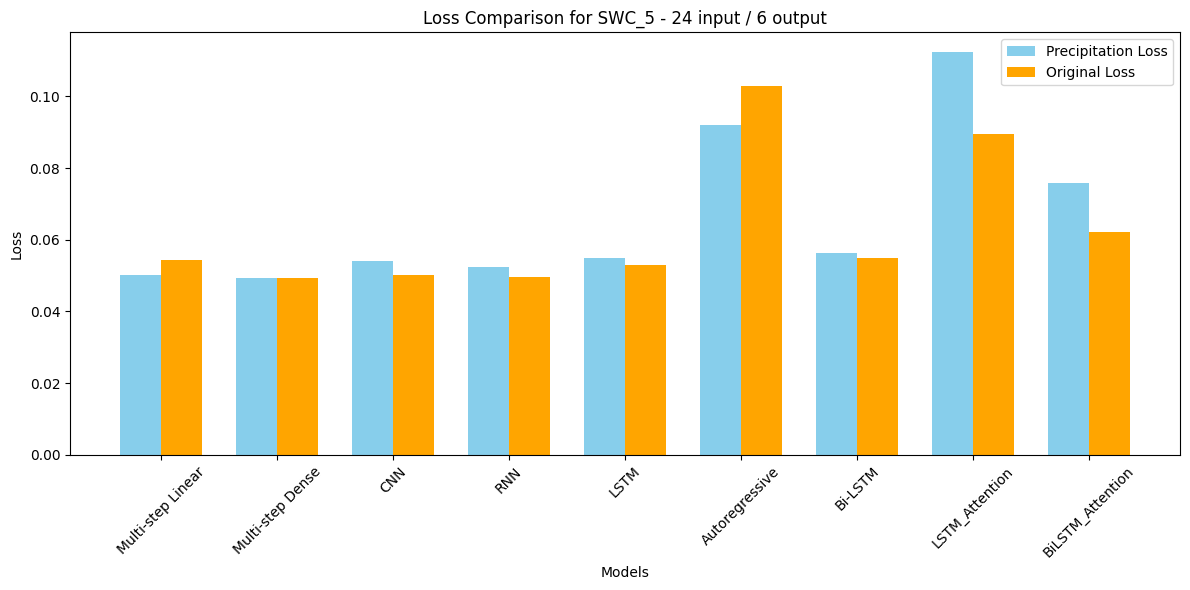

In [17]:
# Filter for a specific configuration (optional)
config = "SWC_5 - 24 input / 6 output"
filtered_data = comp_data[(comp_data["Configuration"] == config) & (comp_data["Model"] != "Baseline")]

# Bar chart for Precipitation Loss vs. Original Loss
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(filtered_data))

plt.bar(index, filtered_data["Precipitation Loss"], bar_width, label="Precipitation Loss", color="skyblue")
plt.bar([i + bar_width for i in index], filtered_data["Original Loss"], bar_width, label="Original Loss", color="orange")

plt.xlabel("Models")
plt.ylabel("Loss")
plt.title(f"Loss Comparison for {config}")
plt.xticks([i + bar_width / 2 for i in index], filtered_data["Model"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


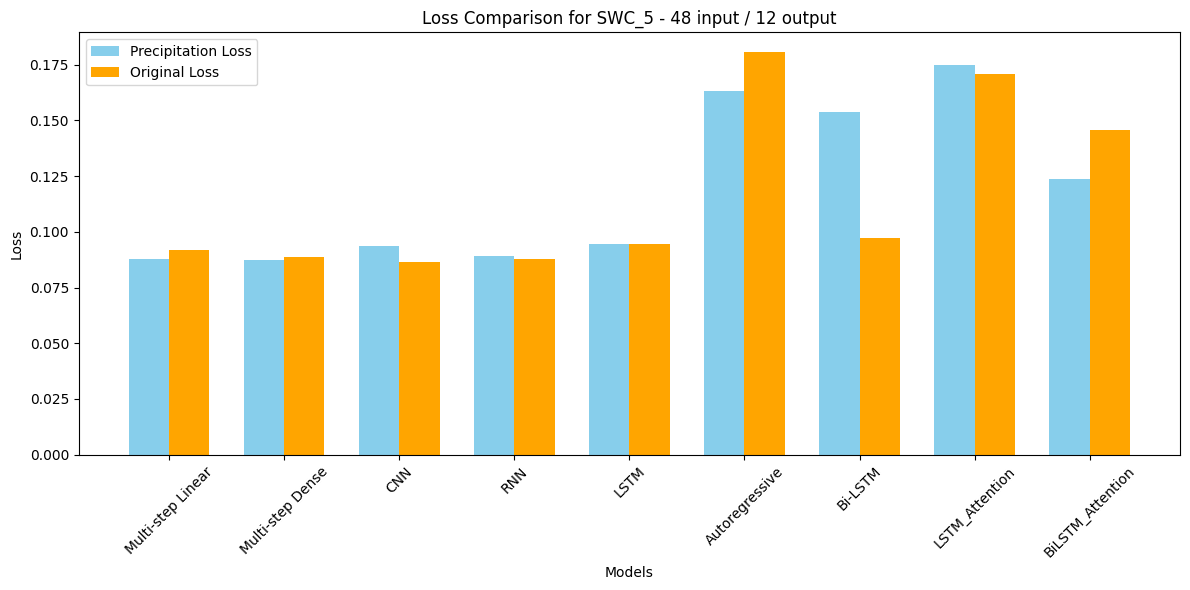

In [24]:
# Filter for a specific configuration (optional)
config = "SWC_5 - 48 input / 12 output"
filtered_data = comp_data[(comp_data["Configuration"] == config) & (comp_data["Model"] != "Baseline")]

# Bar chart for Precipitation Loss vs. Original Loss
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(filtered_data))

plt.bar(index, filtered_data["Precipitation Loss"], bar_width, label="Precipitation Loss", color="skyblue")
plt.bar([i + bar_width for i in index], filtered_data["Original Loss"], bar_width, label="Original Loss", color="orange")

plt.xlabel("Models")
plt.ylabel("Loss")
plt.title(f"Loss Comparison for {config}")
plt.xticks([i + bar_width / 2 for i in index], filtered_data["Model"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


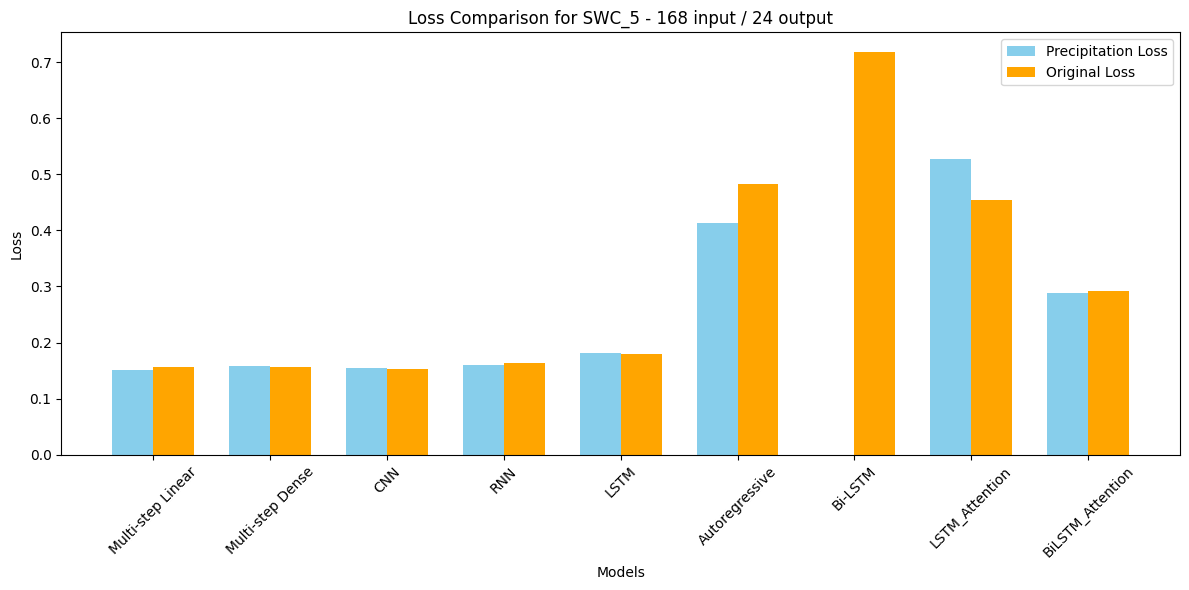

In [25]:
# Filter for a specific configuration (optional)
config = "SWC_5 - 168 input / 24 output"
filtered_data = comp_data[(comp_data["Configuration"] == config) & (comp_data["Model"] != "Baseline")]

# Bar chart for Precipitation Loss vs. Original Loss
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(filtered_data))

plt.bar(index, filtered_data["Precipitation Loss"], bar_width, label="Precipitation Loss", color="skyblue")
plt.bar([i + bar_width for i in index], filtered_data["Original Loss"], bar_width, label="Original Loss", color="orange")

plt.xlabel("Models")
plt.ylabel("Loss")
plt.title(f"Loss Comparison for {config}")
plt.xticks([i + bar_width / 2 for i in index], filtered_data["Model"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


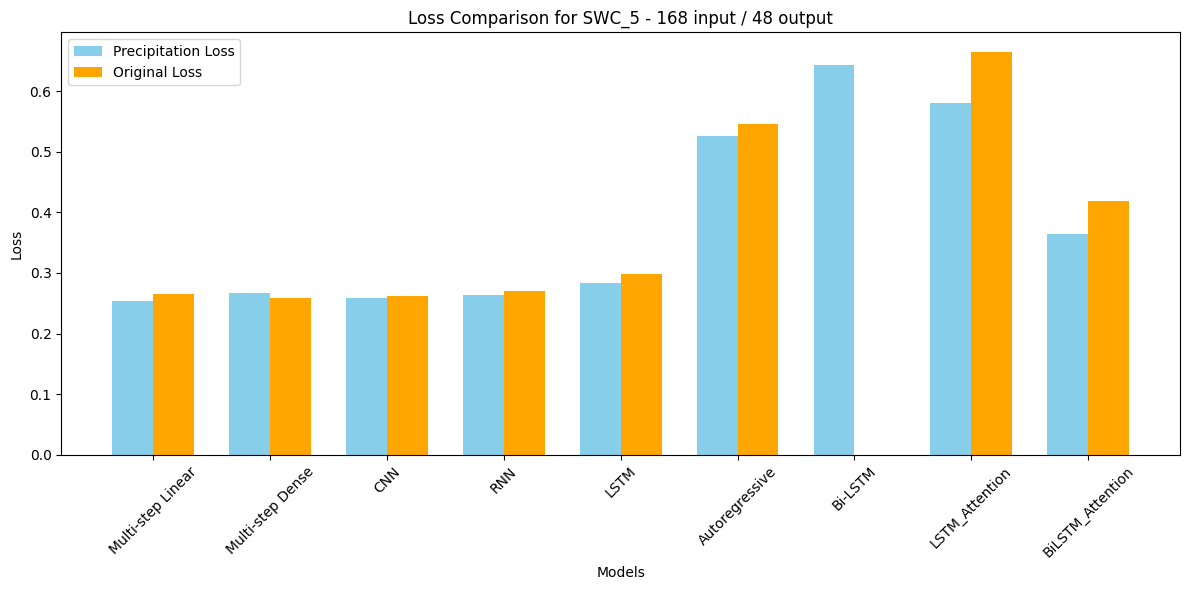

In [26]:
# Filter for a specific configuration (optional)
config = "SWC_5 - 168 input / 48 output"
filtered_data = comp_data[(comp_data["Configuration"] == config) & (comp_data["Model"] != "Baseline")]

# Bar chart for Precipitation Loss vs. Original Loss
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(filtered_data))

plt.bar(index, filtered_data["Precipitation Loss"], bar_width, label="Precipitation Loss", color="skyblue")
plt.bar([i + bar_width for i in index], filtered_data["Original Loss"], bar_width, label="Original Loss", color="orange")

plt.xlabel("Models")
plt.ylabel("Loss")
plt.title(f"Loss Comparison for {config}")
plt.xticks([i + bar_width / 2 for i in index], filtered_data["Model"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


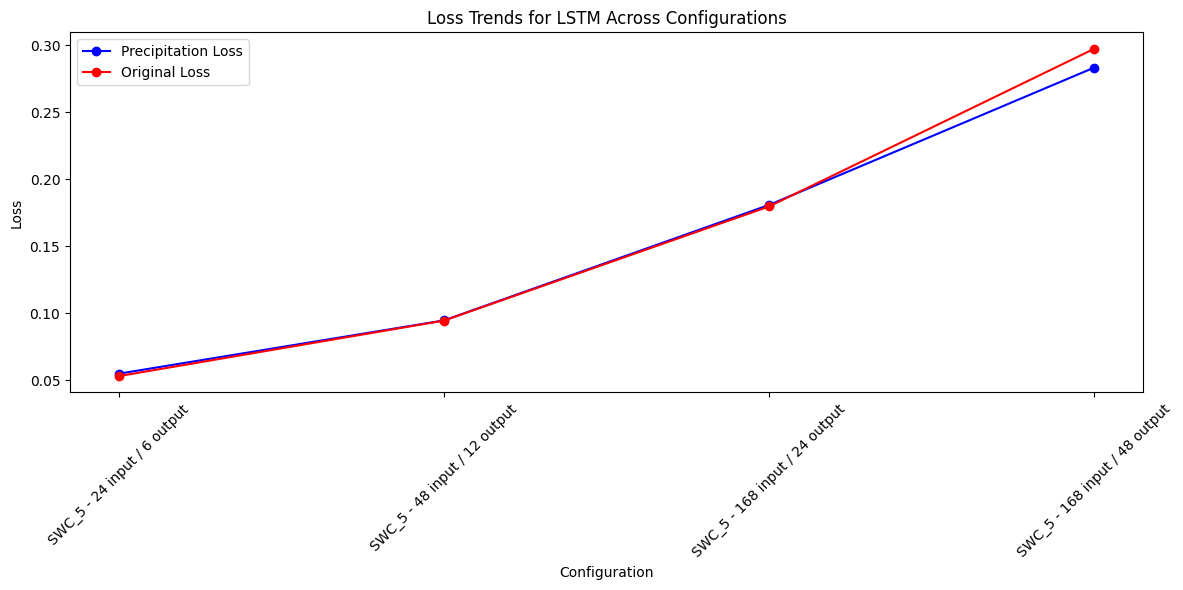

In [18]:
# Line chart for a specific model across configurations
model = "LSTM"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


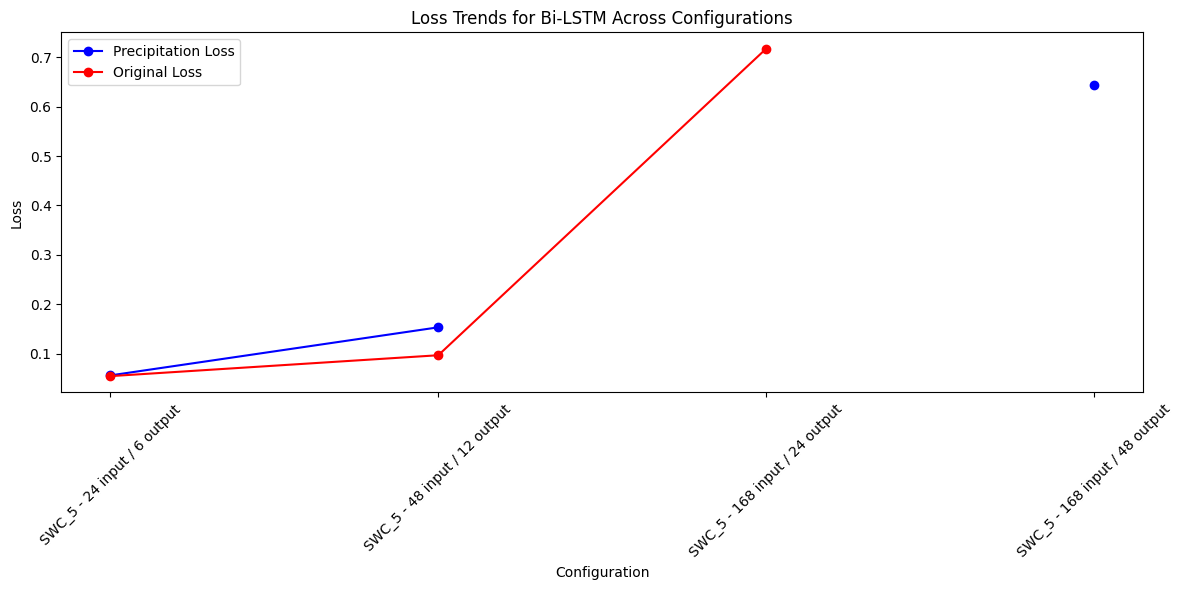

In [27]:
# Line chart for a specific model across configurations
model = "Bi-LSTM"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


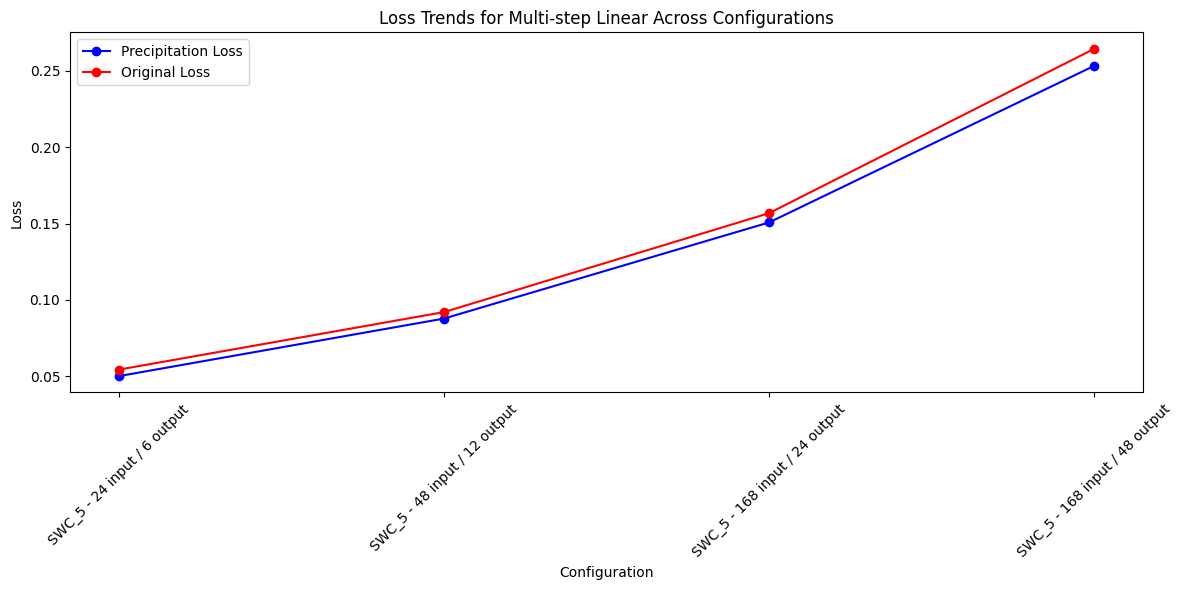

In [28]:
# Line chart for a specific model across configurations
model = "Multi-step Linear"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


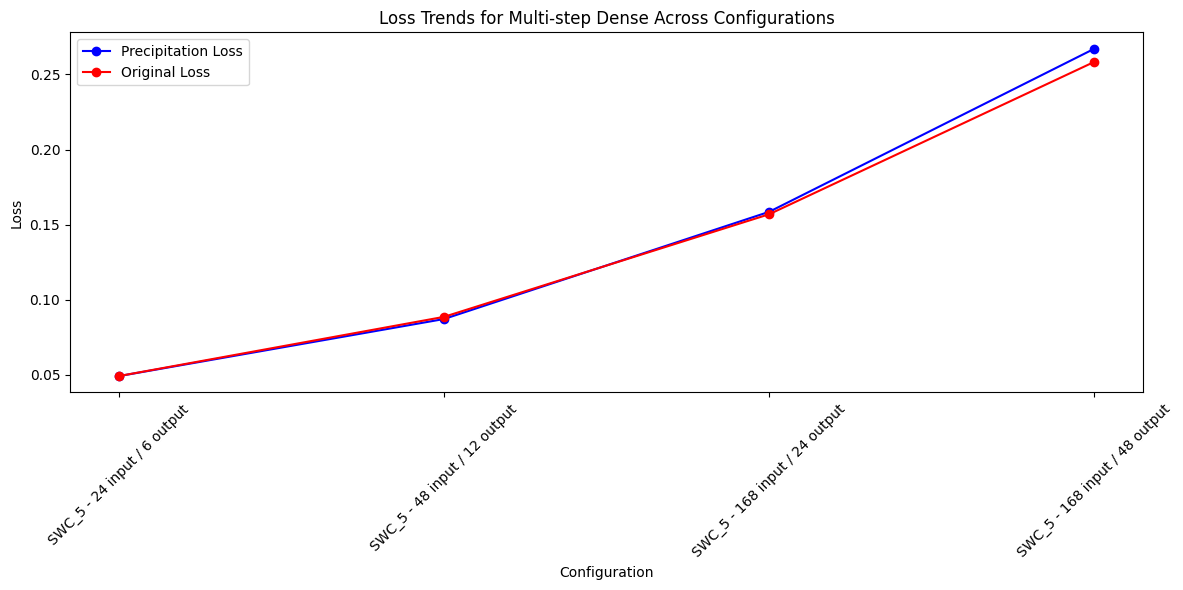

In [29]:
# Line chart for a specific model across configurations
model = "Multi-step Dense"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


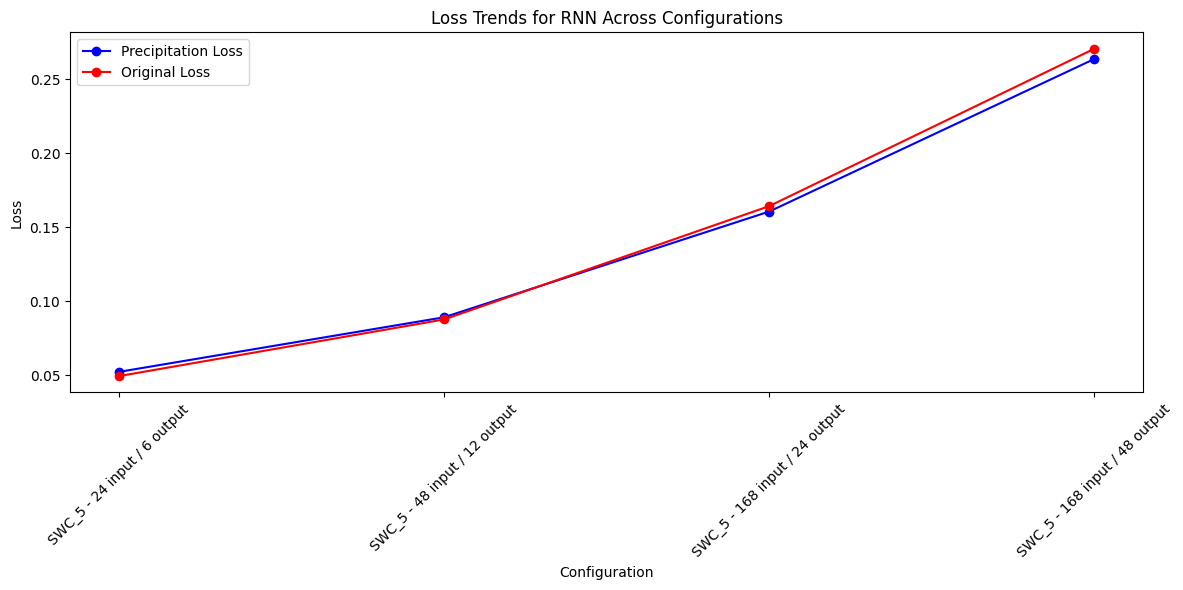

In [30]:
# Line chart for a specific model across configurations
model = "RNN"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


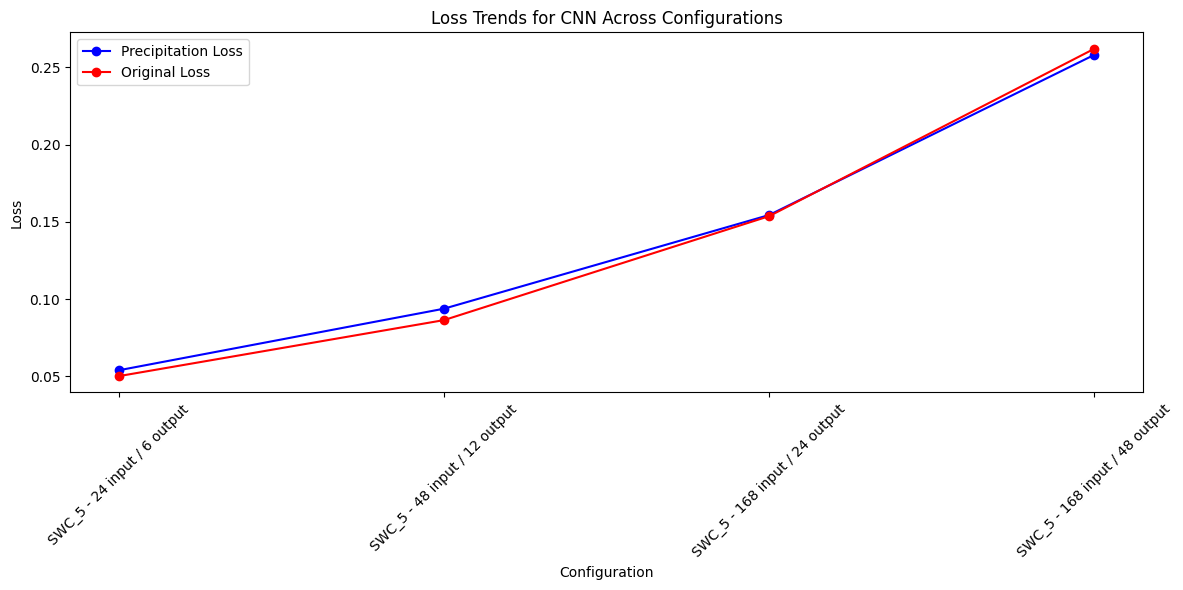

In [31]:
# Line chart for a specific model across configurations
model = "CNN"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


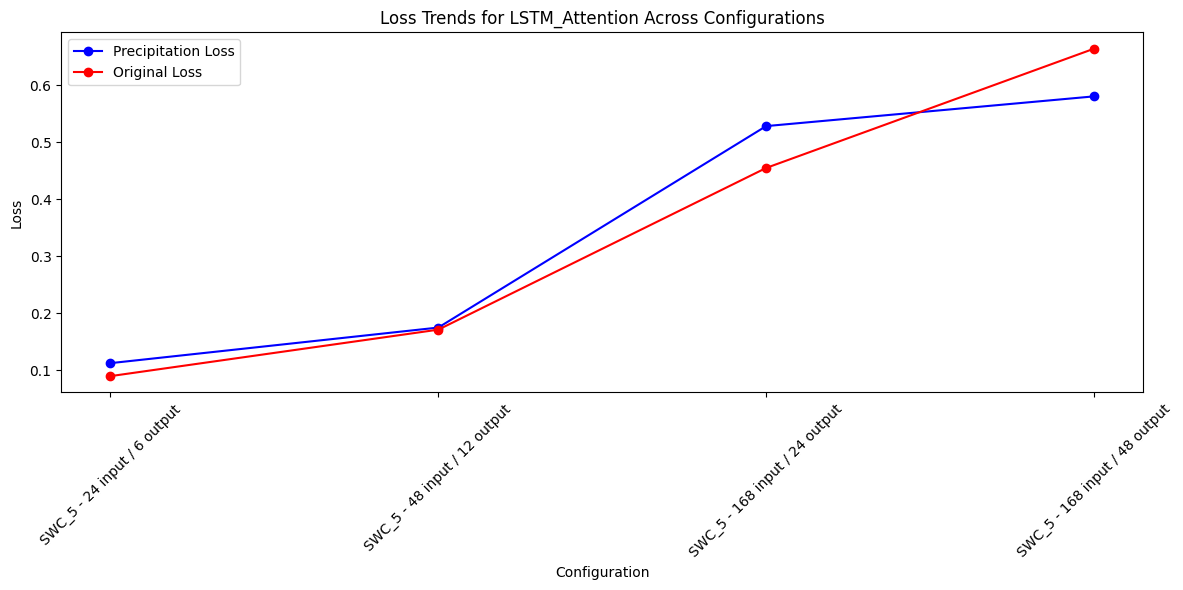

In [32]:
# Line chart for a specific model across configurations
model = "LSTM_Attention"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


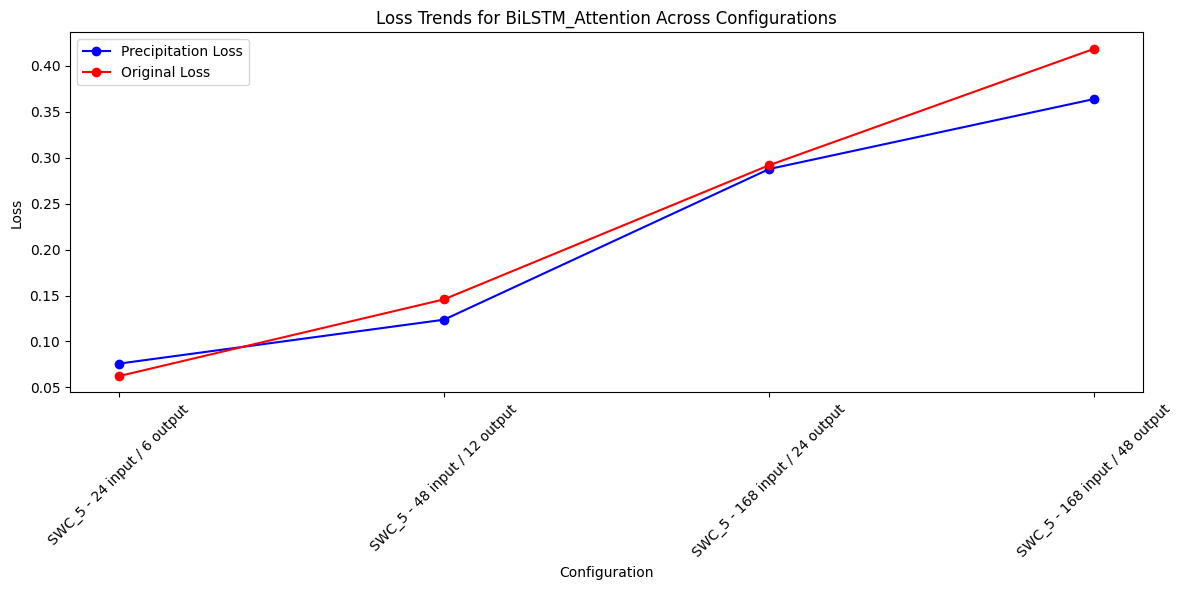

In [33]:
# Line chart for a specific model across configurations
model = "BiLSTM_Attention"
model_data = comp_data[comp_data["Model"] == model]

plt.figure(figsize=(12, 6))
plt.plot(model_data["Configuration"], model_data["Precipitation Loss"], marker="o", label="Precipitation Loss", color="blue")
plt.plot(model_data["Configuration"], model_data["Original Loss"], marker="o", label="Original Loss", color="red")

plt.xlabel("Configuration")
plt.ylabel("Loss")
plt.title(f"Loss Trends for {model} Across Configurations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


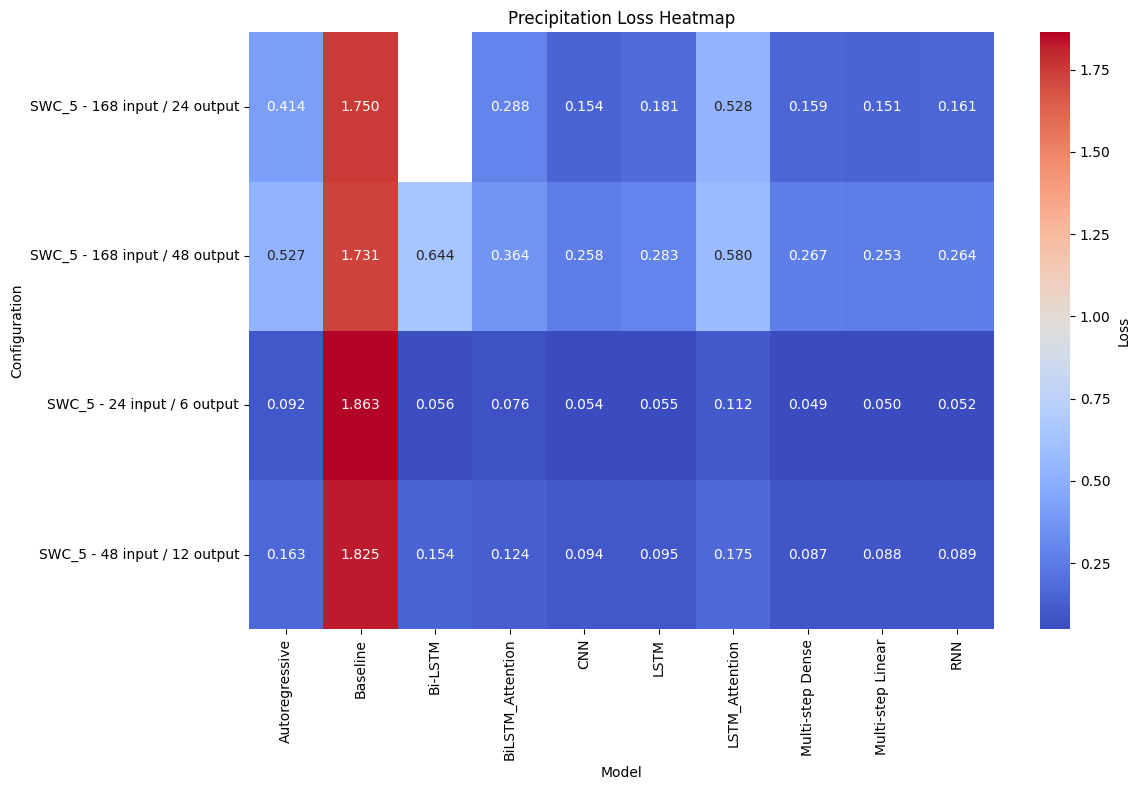

In [20]:
import seaborn as sns

# Prepare pivot table for heatmap
heatmap_data = comp_data.pivot(index="Configuration", columns="Model", values="Precipitation Loss")

# Heatmap for Precipitation Loss
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={"label": "Loss"})
plt.title("Precipitation Loss Heatmap")
plt.ylabel("Configuration")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


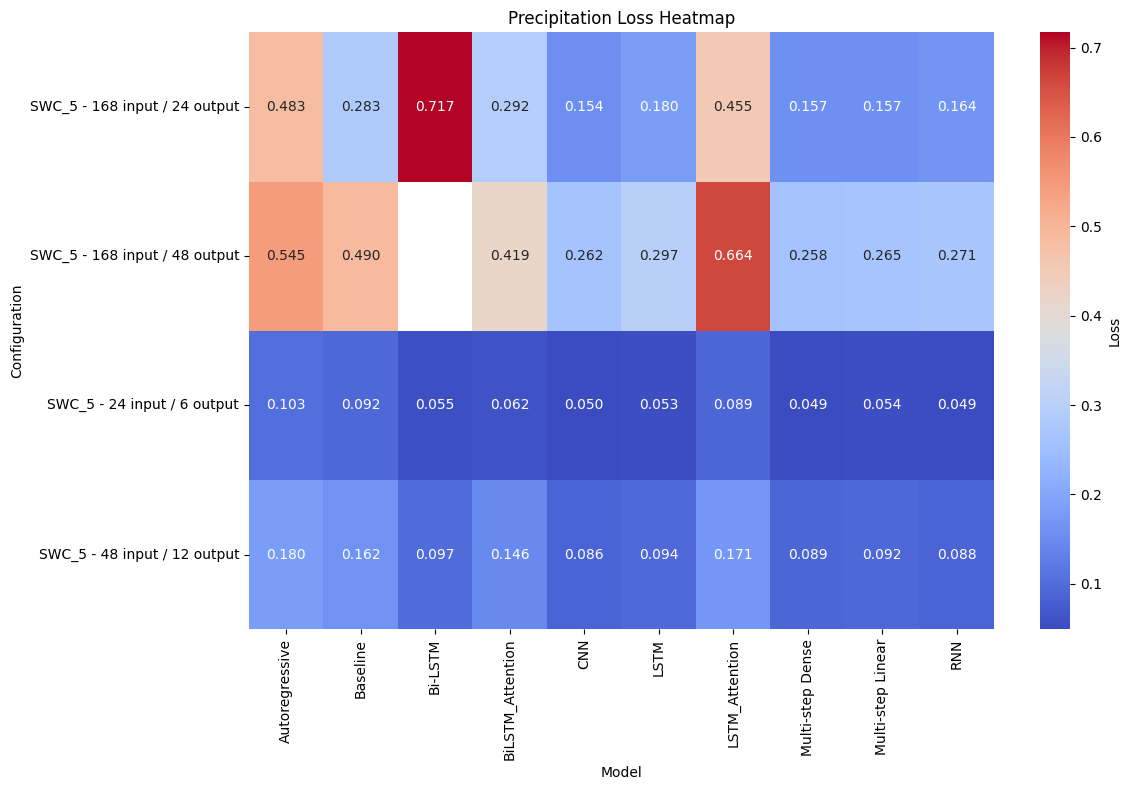

In [21]:

# Prepare pivot table for heatmap
heatmap_data = comp_data.pivot(index="Configuration", columns="Model", values="Original Loss")

# Heatmap for Precipitation Loss
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={"label": "Loss"})
plt.title("Precipitation Loss Heatmap")
plt.ylabel("Configuration")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


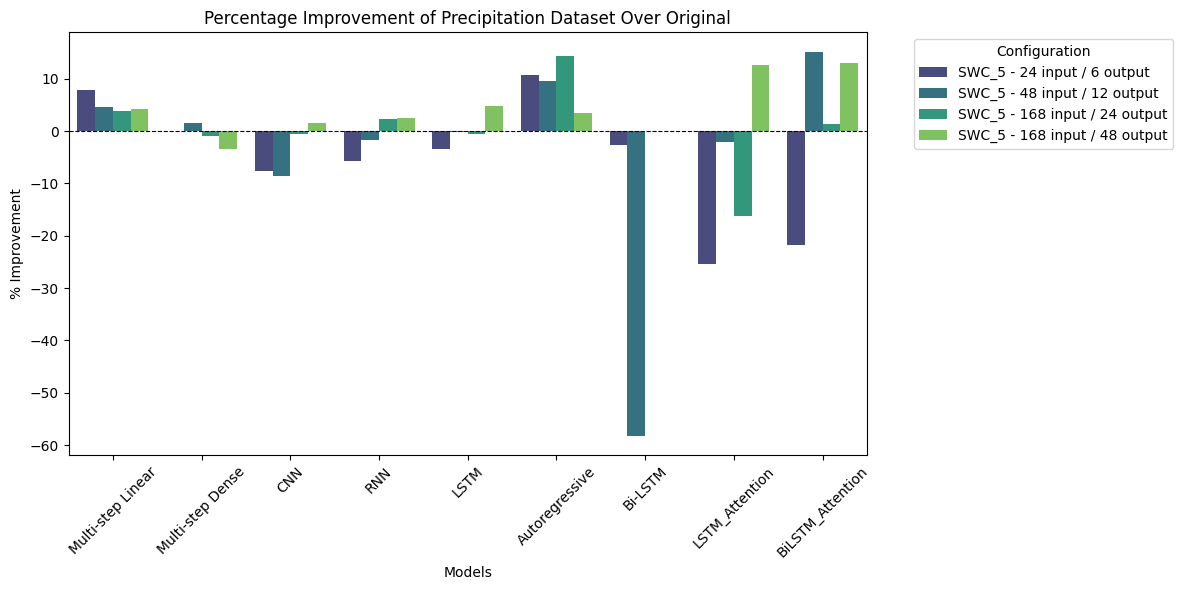

In [23]:
# Bar chart for % Improvement
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="% Improvement", hue="Configuration", data=comp_data[comp_data["Model"] != "Baseline"], palette="viridis")

plt.xlabel("Models")
plt.ylabel("% Improvement")
plt.title("Percentage Improvement of Precipitation Dataset Over Original")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(title="Configuration", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
